# TP01 — Reconnaissance de chiffres (MNIST) — **TensorFlow / Keras**

**M2 DMIA — Deep Learning — Session 1**

Objectif : entraîner votre **premier réseau de neurones** pour reconnaître des chiffres manuscrits, et atteindre un **%** d'accuracy satisfaisante.

On suit le **pipeline DL** standard :
1. Charger les données → 2. Prétraiter → 3. Définir le modèle → 4. Perte + optimiseur → 5. Entraîner → 6. Évaluer → 7. Analyser.

> Recommandé : exécuter sur **Google Colab** (Exécution → Modifier le type d'exécution → GPU).

## 0. Imports et reproductibilité

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproductibilite (la meme graine (seed)-> les memes resultats)
tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow version :', tf.__version__)

TensorFlow version : 2.21.0


## 1. Charger les données

MNIST est intégré à Keras : 60 000 images d'entraînement et 10 000 de test, en niveaux de gris 28×28.

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print('x_train :', x_train.shape, '| y_train :', y_train.shape)
print('x_test  :', x_test.shape,  '| y_test  :', y_test.shape)
print('valeurs des pixels : min =', x_train.min(), ', max =', x_train.max())

x_train : (60000, 28, 28) | y_train : (60000,)
x_test  : (10000, 28, 28) | y_test  : (10000,)
valeurs des pixels : min = 0 , max = 255


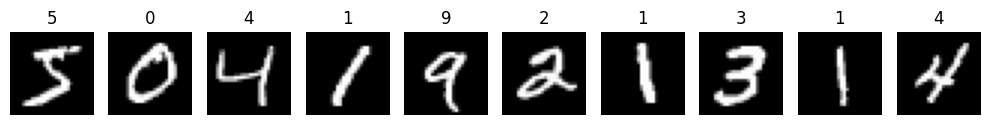

In [3]:
# Visualisons quelques exemples
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(str(y_train[i]))
    plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Prétraiter

Deux étapes :
- **Normaliser** les pixels de [0, 255] vers [0, 1] (l'optimisation converge mieux).
- On garde les labels en entiers (0–9) et on utilisera la perte `sparse_categorical_crossentropy`.

In [4]:
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

print('Apres normalisation : min =', x_train.min(), ', max =', x_train.max())

Apres normalisation : min = 0.0 , max = 1.0


## 3. Définir le modèle

Un réseau **dense** simple : on aplatit l'image (28×28 = 784) puis `784 → 128 → 64 → 10`.
- Couches cachées : activation **ReLU**.
- Couche de sortie : 10 neurones avec **softmax** (probabilités des 10 chiffres).

In [5]:
model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),                      # 28x28 -> 784
    layers.Dense(128, activation='relu'),  # couche cachee 1
    layers.Dense(64, activation='relu'),   # couche cachee 2
    layers.Dense(10, activation='softmax') # sortie : 10 classes
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Perte + optimiseur

- **Optimiseur** : Adam (un bon défaut).
- **Perte** : entropie croisée (`sparse_categorical_crossentropy` car labels entiers).
- **Métrique** : accuracy.

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 5. Entraîner

On entraîne sur 5 époques, avec 10 % des données d'entraînement réservées en **validation** pour surveiller le sur-apprentissage.

In [7]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8979 - loss: 0.3587 - val_accuracy: 0.9593 - val_loss: 0.1425
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9569 - loss: 0.1465 - val_accuracy: 0.9695 - val_loss: 0.1039
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9699 - loss: 0.1011 - val_accuracy: 0.9718 - val_loss: 0.0937
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9778 - loss: 0.0756 - val_accuracy: 0.9727 - val_loss: 0.0892
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9833 - loss: 0.0581 - val_accuracy: 0.9732 - val_loss: 0.0881


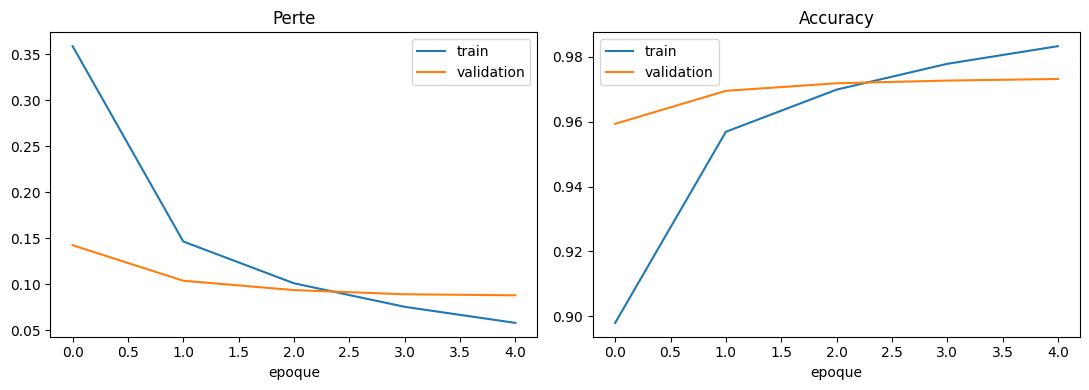

In [8]:
# Courbes d'apprentissage
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Perte'); plt.xlabel('epoque'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.title('Accuracy'); plt.xlabel('epoque'); plt.legend()
plt.tight_layout(); plt.show()

## 6. Évaluer sur le jeu de test

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Accuracy sur le test : {test_acc:.4f}  (perte : {test_loss:.4f})')

Accuracy sur le test : 0.9705  (perte : 0.0964)


## 7. Analyser : matrice de confusion et erreurs

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


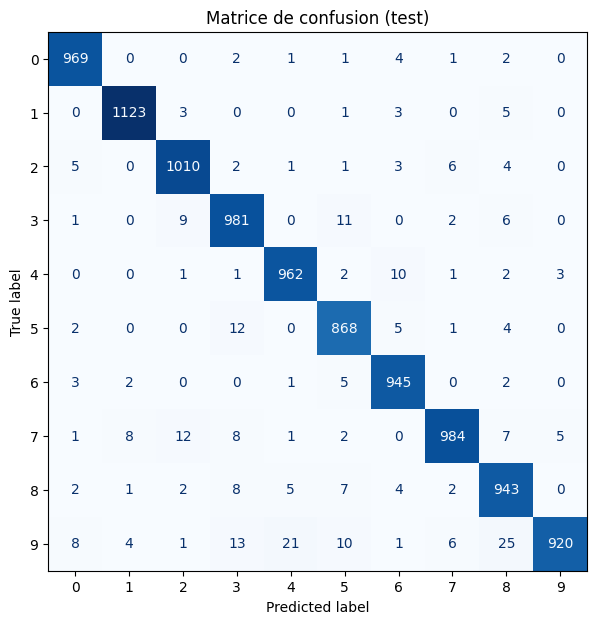

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Matrice de confusion (test)')
plt.show()

Nombre d'erreurs : 295 sur 10000


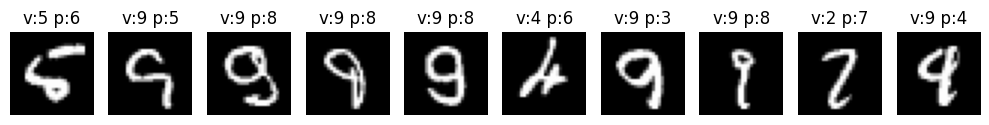

In [11]:
# Quelques erreurs du modele
errors = np.where(y_pred != y_test)[0]
print('Nombre d\'erreurs :', len(errors), 'sur', len(y_test))

plt.figure(figsize=(10, 2))
for i, idx in enumerate(errors[:10]):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f'v:{y_test[idx]} p:{y_pred[idx]}')
    plt.axis('off')
plt.tight_layout(); plt.show()

## 8. À toi de tester

Modifie le réseau et observe l'effet sur l'accuracy de test :
1. **Plus de neurones** : passe la 1ère couche cachée de 128 à 256.
2. **Plus d'époques** : passe de 5 à 10 — l'accuracy continue-t-elle à monter ? Et la validation ?
3. **Plus profond** : ajoute une 3ème couche cachée.
4. **Question** : à partir de quand observes-tu du **sur-apprentissage** (val_loss qui remonte) ?

> Note tes résultats dans un petit tableau (config → accuracy test).

In [12]:
# Ton espace d'experimentation
# ...
